In [ ]:
import os
import re
import pandas as pd

FOLDER = "/content/drive/MyDrive/CAMPAGNA"
OUTFILE = "campagna.csv"

lista_df = []


for fname in os.listdir(FOLDER):
    if fname.lower().endswith(".csv"):
        path = os.path.join(FOLDER, fname)

       
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            meta1 = f.readline().strip()
            meta2 = f.readline().strip()

        
        m_station = re.search(r"Stazione\s*:\s*([A-Za-z0-9_\- ]+?)(?=\s+longitudine|\s+latitudine|$)", meta2, flags=re.I)
        stazione = m_station.group(1).strip() if m_station else os.path.splitext(fname)[0]

        
        m_lon = re.search(r"longitudine\s*:\s*([0-9\.\-]+)", meta2, flags=re.I)
        lon = float(m_lon.group(1)) if m_lon else None

        
        m_lat = re.search(r"latitudine\s*:\s*([0-9\.\-]+)", meta2, flags=re.I)
        lat = float(m_lat.group(1)) if m_lat else None

        
        try:
            df = pd.read_csv(path, skiprows=3, sep=",")
        except:
            df = pd.read_csv(path, skiprows=3, sep=";")

        
        df = df.rename(columns={df.columns[0]: "GIORNO", df.columns[1]: "VALORE"})

       
        df["GIORNO"] = df["GIORNO"].astype(str).str.strip()

        
        df["VALORE"] = pd.to_numeric(df["VALORE"], errors="coerce")

        
        df["Stazione"] = stazione
        df["Lat"] = lat
        df["Lon"] = lon

        
        lista_df.append(df[["GIORNO", "Stazione", "VALORE", "Lat", "Lon"]])



df_finale = pd.concat(lista_df, ignore_index=True)


df_finale.to_csv(OUTFILE, index=False)

print("Creato file unico:", OUTFILE, "con", len(df_finale), "righe")


Creato file unico: campagna.csv con 186280 righe


In [2]:
campagna = pd.read_csv("/content/campagna.csv")

giorni_senza_data = campagna["GIORNO"].isna().sum()
print(giorni_senza_data)

0


In [3]:
separatori = campagna["GIORNO"].str.extract(r'([./-])')[0].value_counts()
print(separatori)

0
-    186280
Name: count, dtype: int64


In [4]:
lunghezza = campagna["GIORNO"].str.len().value_counts()
print(lunghezza)

GIORNO
10    186280
Name: count, dtype: int64


In [5]:
esempi = campagna["GIORNO"].value_counts().head(20)
print(esempi)

GIORNO
2024-12-31    10
1974-01-01    10
1974-01-02    10
1974-01-03    10
2024-12-15    10
2024-12-14    10
2024-12-13    10
2024-12-12    10
2024-12-11    10
2024-12-10    10
2024-12-09    10
2024-12-08    10
2024-12-07    10
2024-12-06    10
2024-12-05    10
2024-12-04    10
2024-12-03    10
2024-12-02    10
2024-12-01    10
2024-11-30    10
Name: count, dtype: int64


In [6]:
righe_vuote = (campagna["GIORNO"].str.strip() == "").sum()
print(f"Righe vuote o solo spazi: {righe_vuote}")

Righe vuote o solo spazi: 0


In [7]:
conteggio_giorni = campagna["GIORNO"].value_counts().sort_index()
print(conteggio_giorni)

GIORNO
1974-01-01    10
1974-01-02    10
1974-01-03    10
1974-01-04    10
1974-01-05    10
              ..
2024-12-27    10
2024-12-28    10
2024-12-29    10
2024-12-30    10
2024-12-31    10
Name: count, Length: 18628, dtype: int64


In [8]:
campagna["GIORNO"] = campagna["GIORNO"].str.strip()

In [9]:
print(campagna["GIORNO"].head(50))

0     1974-01-01
1     1974-01-02
2     1974-01-03
3     1974-01-04
4     1974-01-05
5     1974-01-06
6     1974-01-07
7     1974-01-08
8     1974-01-09
9     1974-01-10
10    1974-01-11
11    1974-01-12
12    1974-01-13
13    1974-01-14
14    1974-01-15
15    1974-01-16
16    1974-01-17
17    1974-01-18
18    1974-01-19
19    1974-01-20
20    1974-01-21
21    1974-01-22
22    1974-01-23
23    1974-01-24
24    1974-01-25
25    1974-01-26
26    1974-01-27
27    1974-01-28
28    1974-01-29
29    1974-01-30
30    1974-01-31
31    1974-02-01
32    1974-02-02
33    1974-02-03
34    1974-02-04
35    1974-02-05
36    1974-02-06
37    1974-02-07
38    1974-02-08
39    1974-02-09
40    1974-02-10
41    1974-02-11
42    1974-02-12
43    1974-02-13
44    1974-02-14
45    1974-02-15
46    1974-02-16
47    1974-02-17
48    1974-02-18
49    1974-02-19
Name: GIORNO, dtype: object


In [10]:
print(campagna["GIORNO"].tail(50))

186230    2024-11-12
186231    2024-11-13
186232    2024-11-14
186233    2024-11-15
186234    2024-11-16
186235    2024-11-17
186236    2024-11-18
186237    2024-11-19
186238    2024-11-20
186239    2024-11-21
186240    2024-11-22
186241    2024-11-23
186242    2024-11-24
186243    2024-11-25
186244    2024-11-26
186245    2024-11-27
186246    2024-11-28
186247    2024-11-29
186248    2024-11-30
186249    2024-12-01
186250    2024-12-02
186251    2024-12-03
186252    2024-12-04
186253    2024-12-05
186254    2024-12-06
186255    2024-12-07
186256    2024-12-08
186257    2024-12-09
186258    2024-12-10
186259    2024-12-11
186260    2024-12-12
186261    2024-12-13
186262    2024-12-14
186263    2024-12-15
186264    2024-12-16
186265    2024-12-17
186266    2024-12-18
186267    2024-12-19
186268    2024-12-20
186269    2024-12-21
186270    2024-12-22
186271    2024-12-23
186272    2024-12-24
186273    2024-12-25
186274    2024-12-26
186275    2024-12-27
186276    2024-12-28
186277    202

In [11]:
def info_date(station_df):
    print(f"Stazione: {station_df['Stazione'].iloc[0]}")
    print("Esempio date:")
    print(station_df["GIORNO"].head(10))  # primi 10 valori
    print("Lunghezze delle date:")
    print(station_df["GIORNO"].str.len().value_counts())
    print("Separatore usato:")
    print(station_df["GIORNO"].str.extract(r'([./-])')[0].value_counts())
    print("-"*40)


for stazione, df_st in campagna.groupby("Stazione"):
    info_date(df_st)

Stazione: Caino
Esempio date:
74512    1974-01-01
74513    1974-01-02
74514    1974-01-03
74515    1974-01-04
74516    1974-01-05
74517    1974-01-06
74518    1974-01-07
74519    1974-01-08
74520    1974-01-09
74521    1974-01-10
Name: GIORNO, dtype: object
Lunghezze delle date:
GIORNO
10    18628
Name: count, dtype: int64
Separatore usato:
0
-    18628
Name: count, dtype: int64
----------------------------------------
Stazione: Casalmaggiore
Esempio date:
111768    1974-01-01
111769    1974-01-02
111770    1974-01-03
111771    1974-01-04
111772    1974-01-05
111773    1974-01-06
111774    1974-01-07
111775    1974-01-08
111776    1974-01-09
111777    1974-01-10
Name: GIORNO, dtype: object
Lunghezze delle date:
GIORNO
10    18628
Name: count, dtype: int64
Separatore usato:
0
-    18628
Name: count, dtype: int64
----------------------------------------
Stazione: Cervesina
Esempio date:
93140    1974-01-01
93141    1974-01-02
93142    1974-01-03
93143    1974-01-04
93144    1974-01-05
93

In [12]:
num_stazioni = campagna["Stazione"].nunique()
print(f"Numero di stazioni nel dataset: {num_stazioni}")

Numero di stazioni nel dataset: 10


In [13]:
campagna["GIORNO"] = pd.to_datetime(campagna["GIORNO"], format="%Y-%m-%d", errors="raise")

In [14]:
conteggio_giorni = campagna.groupby("GIORNO")["Stazione"].nunique()

giorni_incompleti = conteggio_giorni[conteggio_giorni != 10]
print(f"Giorni con numero di stazioni diverso da 10: {len(giorni_incompleti)}")
print(giorni_incompleti)


Giorni con numero di stazioni diverso da 10: 0
Series([], Name: Stazione, dtype: int64)


In [15]:
print(f"Numero totale di righe (len): {len(campagna)}")

Numero totale di righe (len): 186280


In [16]:
full_range = pd.date_range("1974-01-01", "2024-12-31", freq="D")


giorni_presenti = pd.Series(campagna["GIORNO"].unique())

missing_days = full_range.difference(giorni_presenti)

percentuale_mancanti = len(missing_days) / len(full_range) * 100

print(f"Giorni teorici: {len(full_range)}")
print(f"Giorni presenti: {len(giorni_presenti)}")
print(f"Giorni completamente mancanti: {len(missing_days)} ({percentuale_mancanti:.2f}%)")


Giorni teorici: 18628
Giorni presenti: 18628
Giorni completamente mancanti: 0 (0.00%)


In [17]:
campagna["GIORNO"].nunique()

18628

In [18]:
giorni_senza_valore = campagna.groupby("GIORNO")["VALORE"].apply(lambda x: x.isna().all())
giorni_completamente_mancanti = giorni_senza_valore[giorni_senza_valore].index
print(f"Numero di giorni senza alcun valore: {len(giorni_completamente_mancanti)}")

percentuale_mancanti = len(giorni_completamente_mancanti) / campagna["GIORNO"].nunique() * 100
print(f"Percentuale di giorni senza alcun valore: {percentuale_mancanti:.2f}%")

Numero di giorni senza alcun valore: 366
Percentuale di giorni senza alcun valore: 1.96%


Ora faccio la stessa cosa con le Città.

In [19]:
import os
import re
import pandas as pd

FOLDER = "/content/drive/MyDrive/CITTA"
OUTFILE = "citta.csv"

lista_df = []

for fname in os.listdir(FOLDER):
    if fname.lower().endswith(".csv"):
        path = os.path.join(FOLDER, fname)

        # prime 2 righe di metadati
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            meta1 = f.readline().strip()
            meta2 = f.readline().strip()

        # stazione
        m_station = re.search(r"Stazione\s*:\s*([A-Za-z0-9_\- ]+?)(?=\s+longitudine|\s+latitudine|$)", meta2, flags=re.I)
        stazione = m_station.group(1).strip() if m_station else os.path.splitext(fname)[0]

        # longitudine
        m_lon = re.search(r"longitudine\s*:\s*([0-9\.\-]+)", meta2, flags=re.I)
        lon = float(m_lon.group(1)) if m_lon else None

        # latitudine
        m_lat = re.search(r"latitudine\s*:\s*([0-9\.\-]+)", meta2, flags=re.I)
        lat = float(m_lat.group(1)) if m_lat else None

        # leggi dati (le prime 3 righe sono da saltare)
        try:
            df = pd.read_csv(path, skiprows=3, sep=",")
        except:
            df = pd.read_csv(path, skiprows=3, sep=";")

        # colonne giorno e valore
        df = df.rename(columns={df.columns[0]: "GIORNO", df.columns[1]: "VALORE"})

        # Giorno come stringa
        df["GIORNO"] = df["GIORNO"].astype(str).str.strip()

        # VALORE in numerico
        df["VALORE"] = pd.to_numeric(df["VALORE"], errors="coerce")

        # metadati
        df["Stazione"] = stazione
        df["Lat"] = lat
        df["Lon"] = lon

        # dataset finale
        lista_df.append(df[["GIORNO", "Stazione", "VALORE", "Lat", "Lon"]])


df_finale = pd.concat(lista_df, ignore_index=True)

df_finale.to_csv(OUTFILE, index=False)

print("Creato file unico:", OUTFILE, "con", len(df_finale), "righe")


Creato file unico: citta.csv con 167652 righe


In [20]:
citta = pd.read_csv("/content/citta.csv")

giorni_senza_data = citta["GIORNO"].isna().sum()
print(giorni_senza_data)

0


In [21]:
separatori = citta["GIORNO"].str.extract(r'([./-])')[0].value_counts()
print(separatori)

0
-    167652
Name: count, dtype: int64


In [22]:
lunghezza = citta["GIORNO"].str.len().value_counts()
print(lunghezza)

GIORNO
10    167652
Name: count, dtype: int64


In [23]:
esempi = citta["GIORNO"].value_counts().head(20)
print(esempi)

GIORNO
2024-12-31    9
1974-01-01    9
1974-01-02    9
1974-01-03    9
2024-12-15    9
2024-12-14    9
2024-12-13    9
2024-12-12    9
2024-12-11    9
2024-12-10    9
2024-12-09    9
2024-12-08    9
2024-12-07    9
2024-12-06    9
2024-12-05    9
2024-12-04    9
2024-12-03    9
2024-12-02    9
2024-12-01    9
2024-11-30    9
Name: count, dtype: int64


In [24]:
righe_vuote = (citta["GIORNO"].str.strip() == "").sum()
print(f"Righe vuote o solo spazi: {righe_vuote}")

Righe vuote o solo spazi: 0


In [25]:
citta["GIORNO"] = citta["GIORNO"].str.strip()

In [26]:
def info_date(station_df):
    print(f"Stazione: {station_df['Stazione'].iloc[0]}")
    print("Esempio date:")
    print(station_df["GIORNO"].head(10))  # primi 10 valori
    print("Lunghezze delle date:")
    print(station_df["GIORNO"].str.len().value_counts())
    print("Separatore usato:")
    print(station_df["GIORNO"].str.extract(r'([./-])')[0].value_counts())
    print("-"*40)


for stazione, df_st in citta.groupby("Stazione"):
    info_date(df_st)

Stazione: BERGAMO
Esempio date:
37256    1974-01-01
37257    1974-01-02
37258    1974-01-03
37259    1974-01-04
37260    1974-01-05
37261    1974-01-06
37262    1974-01-07
37263    1974-01-08
37264    1974-01-09
37265    1974-01-10
Name: GIORNO, dtype: object
Lunghezze delle date:
GIORNO
10    18628
Name: count, dtype: int64
Separatore usato:
0
-    18628
Name: count, dtype: int64
----------------------------------------
Stazione: BRESCIA
Esempio date:
0    1974-01-01
1    1974-01-02
2    1974-01-03
3    1974-01-04
4    1974-01-05
5    1974-01-06
6    1974-01-07
7    1974-01-08
8    1974-01-09
9    1974-01-10
Name: GIORNO, dtype: object
Lunghezze delle date:
GIORNO
10    18628
Name: count, dtype: int64
Separatore usato:
0
-    18628
Name: count, dtype: int64
----------------------------------------
Stazione: Como
Esempio date:
130396    1974-01-01
130397    1974-01-02
130398    1974-01-03
130399    1974-01-04
130400    1974-01-05
130401    1974-01-06
130402    1974-01-07
130403    1974

In [27]:
num_stazioni = citta["Stazione"].nunique()
print(f"Numero di stazioni nel dataset: {num_stazioni}")

Numero di stazioni nel dataset: 8


In [28]:
stazioni_uniche = citta["Stazione"].unique()
print("Stazioni uniche rilevate:")
print(stazioni_uniche)

conteggio_stazioni = citta["Stazione"].value_counts()
print("\nConteggio righe per ciascuna stazione:")
print(conteggio_stazioni)

Stazioni uniche rilevate:
['BRESCIA' 'MILANO' 'BERGAMO' 'Pavia' 'Mantova' 'Monza' 'Como' 'Cremona']

Conteggio righe per ciascuna stazione:
Stazione
Pavia      37256
BRESCIA    18628
MILANO     18628
BERGAMO    18628
Mantova    18628
Monza      18628
Como       18628
Cremona    18628
Name: count, dtype: int64


Pavia appare il doppio delle volte, ma questo perche ho selezionato sia la stazione ARPA di Pavia sia quella idrologica. Questo perchè coprivano range temporali diversi.

In [29]:
citta["GIORNO"] = pd.to_datetime(citta["GIORNO"], format="%Y-%m-%d", errors="raise")

In [30]:
conteggio_giorni = citta.groupby("GIORNO")["Stazione"].nunique()

giorni_incompleti = conteggio_giorni[conteggio_giorni != 8]
print(f"Giorni con numero di stazioni diverso da 8: {len(giorni_incompleti)}")
print(giorni_incompleti)

Giorni con numero di stazioni diverso da 8: 0
Series([], Name: Stazione, dtype: int64)


In [31]:
print(f"Numero totale di righe (len): {len(citta)}")

Numero totale di righe (len): 167652


In [32]:
full_range = pd.date_range("1974-01-01", "2024-12-31", freq="D")

giorni_presenti_citta = pd.Series(citta["GIORNO"].unique())

missing_days_citta = full_range.difference(giorni_presenti_citta)

percentuale_mancanti_citta = len(missing_days_citta) / len(full_range) * 100

print(f"Giorni teorici: {len(full_range)}")
print(f"Giorni presenti: {len(giorni_presenti_citta)}")
print(f"Giorni completamente mancanti: {len(missing_days_citta)} ({percentuale_mancanti_citta:.2f}%)")

Giorni teorici: 18628
Giorni presenti: 18628
Giorni completamente mancanti: 0 (0.00%)


In [33]:
giorni_senza_valore_citta = citta.groupby("GIORNO")["VALORE"].apply(lambda x: x.isna().all())
giorni_completamente_mancanti_citta = giorni_senza_valore_citta[giorni_senza_valore_citta].index
print(f"Numero di giorni senza alcun valore: {len(giorni_completamente_mancanti_citta)}")

percentuale_mancanti_citta = len(giorni_completamente_mancanti_citta) / citta["GIORNO"].nunique() * 100
print(f"Percentuale di giorni senza alcun valore: {percentuale_mancanti_citta:.2f}%")

Numero di giorni senza alcun valore: 1
Percentuale di giorni senza alcun valore: 0.01%


In [34]:
giorni_senza_valore_urbano = citta.groupby('GIORNO')['VALORE'].apply(lambda x: x.isna().all())
percentuale_senza_valore_urbano = (giorni_senza_valore_urbano.sum() / len(giorni_senza_valore_urbano)) * 100

print(f"Percentuale di giorni senza dati: {percentuale_senza_valore_urbano:.2f}%")


Percentuale di giorni senza dati: 0.01%


Ora che ho effettuato l'estrazione e la pulizia dei dati posso procedere con l'analisi. Iniziando con il dataset rurale ("campagna")

In [35]:
rurale = campagna.groupby(["GIORNO"]).max().drop(["Stazione","Lat", "Lon"], axis=1).squeeze()
rurale

,VALORE
GIORNO,
1974-01-01,7.6
1974-01-02,7.2
1974-01-03,8.4
1974-01-04,8.0
1974-01-05,7.0
...,...
2024-12-27,11.9
2024-12-28,13.2
2024-12-29,14.0


In [36]:
print(len(rurale))

18628


In [37]:
!pip install pyextremes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.3 MB/s eta 0:00:00


In [38]:
from pyextremes import EVA

model_rurale = EVA(rurale)

/usr/local/lib/python3.12/dist-packages/pyextremes/eva.py:131: RuntimeWarning: 366 Null values found in `data` - removing invalid entries
  warnings.warn(message=message, category=RuntimeWarning)


In [39]:
model_rurale.get_extremes(method="BM", block_size="365.2425D",errors="coerce")

/usr/local/lib/python3.12/dist-packages/pyextremes/extremes/block_maxima.py:138: NoDataBlockWarning: 1 blocks contained no data
  warnings.warn(


In [40]:
print(len(model_rurale.extremes))
model_rurale.extremes

51


,VALORE
GIORNO,
1974-08-16 00:00:00,35.600
1975-07-19 00:00:00,35.000
1976-07-16 00:00:00,34.000
1977-07-12 00:00:00,33.000
1978-06-05 00:00:00,31.000
1979-08-02 00:00:00,34.200
1980-08-02 00:00:00,34.000
1981-08-05 00:00:00,41.000
1982-07-07 00:00:00,36.000


(<Figure size 768x480 with 1 Axes>, <Axes: xlabel='GIORNO', ylabel='VALORE'>)

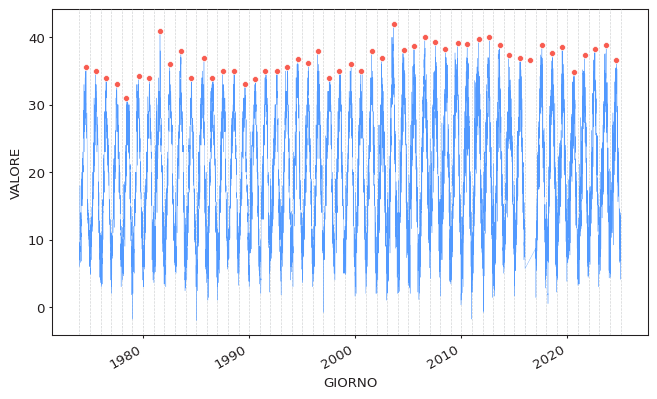

In [41]:
model_rurale.plot_extremes()

In [42]:
df = model_rurale.data

empty_years = df.resample("A").count()
empty_years = empty_years[empty_years == 0]

print("Anni senza dati:")
print(empty_years.index.year.tolist())

Anni senza dati:
[2016]


/tmp/ipython-input-3114431213.py:3: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  empty_years = df.resample("A").count()


In [43]:
model_rurale.extremes.sort_values(ascending=False)

,VALORE
GIORNO,
2003-08-12 00:00:00,42.000
1981-08-05 00:00:00,41.000
2006-07-23 00:00:00,40.000
2012-08-22 00:00:00,40.000
2011-08-22 00:00:00,39.800
2007-07-19 00:00:00,39.300
2009-08-20 00:00:00,39.100
2010-07-17 00:00:00,39.000
2017-08-03 00:00:00,38.900


In [44]:
model_rurale.fit_model()

In [45]:
summary_rurale = model_rurale.get_summary(
    return_period=[1, 2, 5, 10, 50, 100],
    alpha=0.95,
    n_samples=10000,
)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [46]:
summary_rurale

,return value,lower ci,upper ci
return period,,,
1.0,-inf,NaN,NaN
2.0,36.678137,35.918292,37.436674
5.0,38.670407,37.840887,39.379047
10.0,39.666271,38.784086,40.366892
50.0,41.215157,39.756509,42.444879
100.0,41.674084,39.930566,43.473949


(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='VALORE'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='VALORE', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

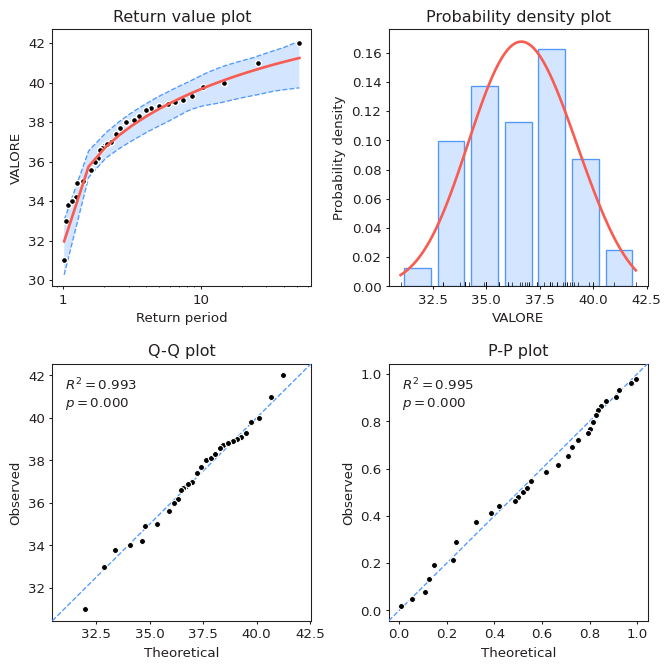

In [47]:
model_rurale.plot_diagnostic(alpha=0.95)

In [48]:
model_rurale.distribution

            pyextremes distribution             
------------------------------------------------
name: genextreme                                
free parameters: c, loc, scale                  
fixed parameters: all parameters are free       
MLE parameters: c=0.296, loc=35.877, scale=2.305
------------------------------------------------

In [49]:
from pyextremes import get_return_periods

return_periods_rurale = get_return_periods(
    ts=rurale,
    extremes=model_rurale.extremes,
    extremes_method="BM",
    extremes_type="high",
    block_size="365.2425D",
    return_period_size="365.2425D",
    plotting_position="weibull",
)
return_periods_rurale.sort_values("return period", ascending=False).head(10)

,VALORE,exceedance probability,return period
GIORNO,,,
2003-08-12,42.0,0.019231,52.000000
1981-08-05,41.0,0.038462,26.000000
2006-07-23,40.0,0.067308,14.857143
2012-08-22,40.0,0.067308,14.857143
2011-08-22,39.8,0.096154,10.400000
2007-07-19,39.3,0.115385,8.666667
2009-08-20,39.1,0.134615,7.428571
2010-07-17,39.0,0.153846,6.500000
2017-08-03,38.9,0.173077,5.777778


Ora faccio la POT, e per farla devo scegliere il valore di soglia.

In [50]:
model_rurale1 = EVA(rurale)

/usr/local/lib/python3.12/dist-packages/pyextremes/eva.py:131: RuntimeWarning: 366 Null values found in `data` - removing invalid entries
  warnings.warn(message=message, category=RuntimeWarning)


In [51]:
print(rurale.head())

GIORNO
1974-01-01    7.6
1974-01-02    7.2
1974-01-03    8.4
1974-01-04    8.0
1974-01-05    7.0
Name: VALORE, dtype: float64


In [52]:
rurale.describe()

,VALORE
count,18262.000000
mean,19.983561
std,9.057537
min,-2.000000
25%,12.000000
50%,20.000000
75%,28.000000
max,42.000000


In [53]:
print(rurale.isna().sum())

366


In [54]:
rurale1 = rurale.dropna()

<Axes: xlabel='Threshold', ylabel='Mean excess'>

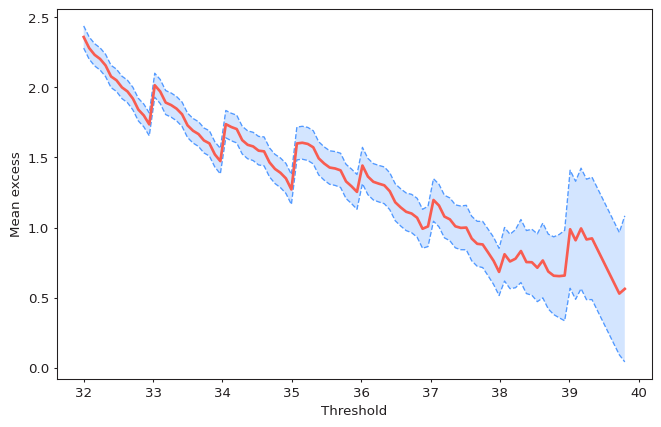

In [55]:
from pyextremes import plot_mean_residual_life

plot_mean_residual_life(rurale1)

Guardando il grafico, che mostra di base un andamento poco lineare, riconosco una certa linearità e bande di confidenza più strette intorno ad un valore di soglia di 32°C.

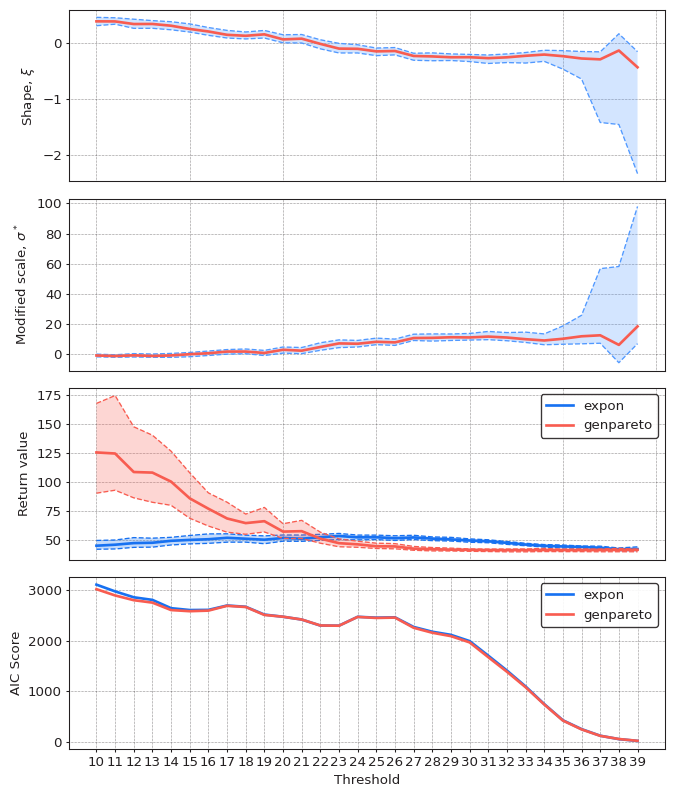

In [56]:
from pyextremes import plot_threshold_stability
import numpy as np
import matplotlib.pyplot as plt

plot_threshold_stability(
    rurale1,
    return_period=100,
    thresholds=np.linspace(10, 39, 30),
    alpha=0.95
)
plt.xticks(np.arange(10, 40, 1))
plt.show()

Osservando i grafici di forma, scala, valore di ritorno e valore di AIC i valori di soglia più stabili sembrano essere quelli tra i 32°C e i 35°C.

In [57]:
import numpy as np

percentile = 90
soglia = np.percentile(rurale1, percentile)
print(f"Soglia corrispondente al {percentile}° percentile: {soglia}")


Soglia corrispondente al 90° percentile: 32.0


In [58]:
rurale1

,VALORE
GIORNO,
1974-01-01,7.6
1974-01-02,7.2
1974-01-03,8.4
1974-01-04,8.0
1974-01-05,7.0
...,...
2024-12-27,11.9
2024-12-28,13.2
2024-12-29,14.0


In [59]:
model_rurale1.get_extremes("POT", threshold= 32.0, r="7D")

(<Figure size 768x480 with 1 Axes>, <Axes: xlabel='GIORNO', ylabel='VALORE'>)

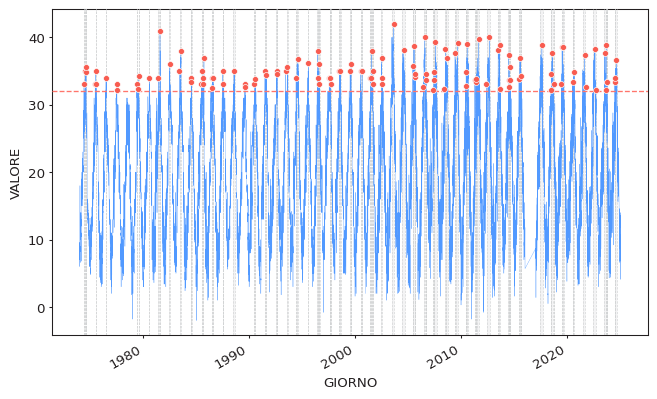

In [60]:
model_rurale1.plot_extremes(show_clusters=True)

In [61]:
print(len(model_rurale1.extremes))
model_rurale1.extremes

128


,VALORE
GIORNO,
1974-06-05,33.0
1974-07-18,35.0
1974-08-04,34.8
1974-08-16,35.6
1975-06-26,33.0
...,...
2023-09-12,33.3
2023-10-09,33.3
2024-06-18,33.4


In [62]:
model_rurale1.extremes.sort_values(ascending=False)

,VALORE
GIORNO,
2003-08-12,42.0
1981-08-05,41.0
2006-07-23,40.0
2012-08-22,40.0
2011-08-22,39.8
...,...
1977-07-03,32.2
2007-05-10,32.2
2018-06-09,32.2


In [63]:
model_rurale1.fit_model()

In [99]:
summary_rurale1 = model_rurale1.get_summary(
    return_period=[1, 2, 5, 10, 50, 100],
    alpha=0.95,
    n_samples=5000,
)

In [100]:
summary_rurale1

,return value,lower ci,upper ci
return period,,,
1.0,35.230304,34.770258,35.810856
2.0,37.019566,36.396197,37.692056
5.0,38.767721,37.970714,39.422009
10.0,39.740946,38.759725,40.383283
50.0,41.221172,39.673714,41.951777
100.0,41.628417,39.875367,42.494031


(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='VALORE'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='VALORE', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

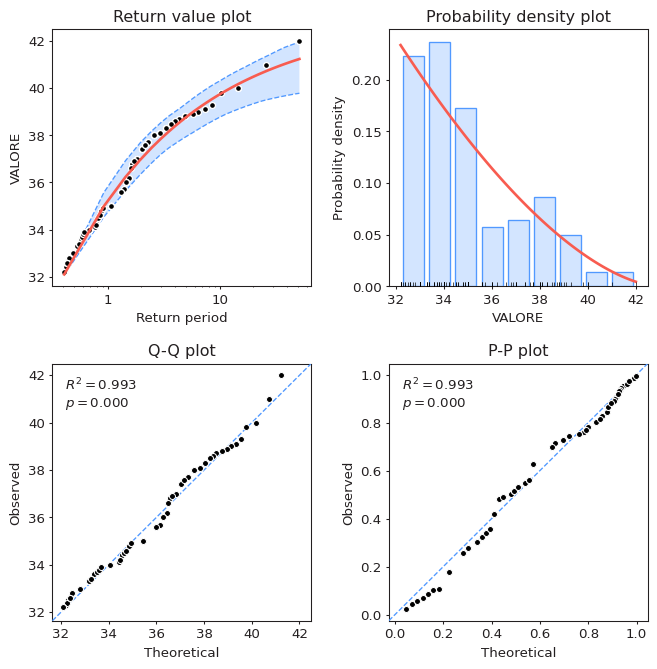

In [101]:
model_rurale1.plot_diagnostic(alpha=0.95)

In [67]:
model_rurale1.distribution

       pyextremes distribution       
-------------------------------------
name: genpareto                      
free parameters: c, scale            
fixed parameters: floc=32.000        
MLE parameters: c=-0.378, scale=4.157
-------------------------------------

In [102]:
from pyextremes import get_return_periods

return_periods = get_return_periods(
    ts=rurale1,
    extremes=model_rurale1.extremes,
    extremes_method="POT",
    extremes_type="high",
    block_size=None,
    return_period_size="365.2425D",
    plotting_position="weibull",
)
return_periods.sort_values("return period", ascending=False).head()

,VALORE,exceedance probability,return period
GIORNO,,,
2003-08-12,42.0,0.007752,51.397423
1981-08-05,41.0,0.015504,25.698712
2006-07-23,40.0,0.027132,14.684978
2012-08-22,40.0,0.027132,14.684978
2011-08-22,39.8,0.038760,10.279485


Ora faccio lo stesso con il dataset urbano.

In [69]:
urbano = citta.groupby(["GIORNO"]).max().drop(["Stazione","Lat", "Lon"], axis=1).squeeze()
urbano

,VALORE
GIORNO,
1974-01-01,5.4
1974-01-02,7.0
1974-01-03,6.8
1974-01-04,9.0
1974-01-05,6.0
...,...
2024-12-27,11.7
2024-12-28,13.1
2024-12-29,14.0


In [70]:
print(len(urbano))

18628


In [71]:
from pyextremes import EVA

model_urbano = EVA(urbano)

/usr/local/lib/python3.12/dist-packages/pyextremes/eva.py:131: RuntimeWarning: 1 Null values found in `data` - removing invalid entries
  warnings.warn(message=message, category=RuntimeWarning)


In [72]:
model_urbano.get_extremes(method="BM", block_size="365.2425D",errors="coerce")

In [73]:
print(len(model_urbano.extremes))
model_urbano.extremes

51


,VALORE
GIORNO,
1974-08-16,36.2
1975-07-25,38.0
1976-07-17,35.0
1977-07-13,33.8
1978-09-11,32.4
1979-08-05,39.0
1980-08-03,35.5
1981-06-16,34.0
1982-07-06,38.5


(<Figure size 768x480 with 1 Axes>, <Axes: xlabel='GIORNO', ylabel='VALORE'>)

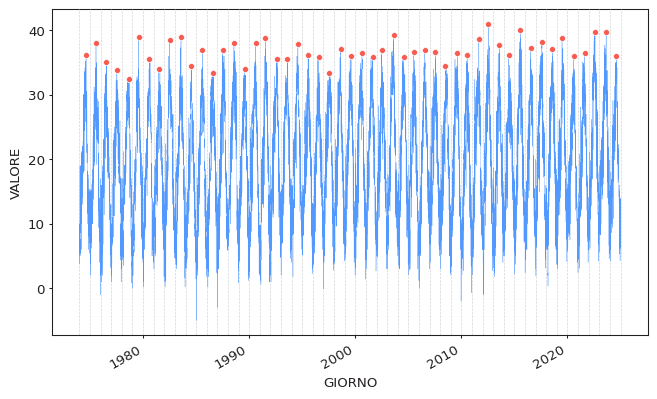

In [74]:
model_urbano.plot_extremes()

In [75]:
model_urbano.extremes.sort_values(ascending=False)

,VALORE
GIORNO,
2012-07-21,41.0
2015-07-22,40.0
2022-08-05,39.8
2023-08-23,39.7
2003-08-11,39.3
1983-07-28,39.0
1979-08-05,39.0
2019-06-27,38.8
1991-07-08,38.8


In [76]:
model_urbano.fit_model()

In [77]:
summary_urbano = model_urbano.get_summary(
    return_period=[1, 2, 5, 10, 50, 100],
    alpha=0.95,
    n_samples=10000,
)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [78]:
summary_urbano

,return value,lower ci,upper ci
return period,,,
1.0,-inf,NaN,NaN
2.0,36.759021,36.201502,37.359043
5.0,38.374953,37.754306,38.934911
10.0,39.173384,38.453975,39.718054
50.0,40.398113,39.381433,41.072612
100.0,40.755636,39.604552,41.600476


(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='VALORE'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='VALORE', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

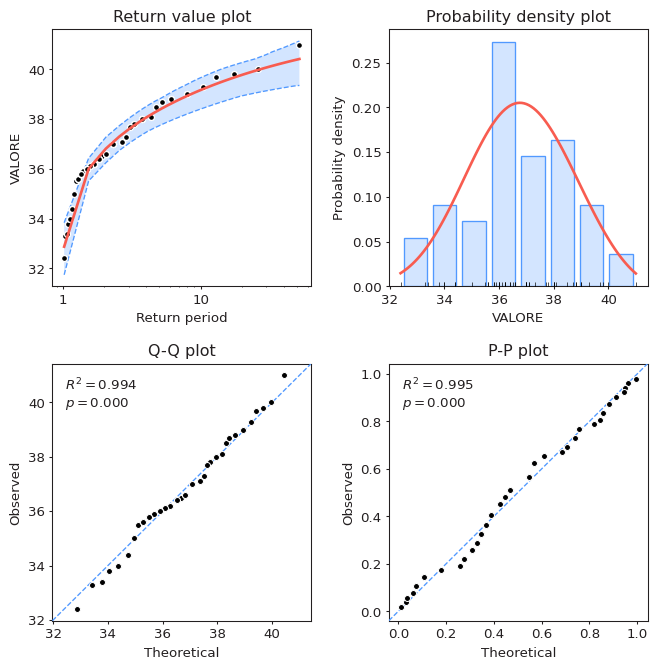

In [79]:
model_urbano.plot_diagnostic(alpha=0.95)

In [80]:
from pyextremes import get_return_periods

return_periods = get_return_periods(
    ts=urbano,
    extremes=model_urbano.extremes,
    extremes_method="BM",
    extremes_type="high",
    block_size="365.2425D",
    return_period_size="365.2425D",
    plotting_position="weibull",
)
return_periods.sort_values("return period", ascending=False).head()

,VALORE,exceedance probability,return period
GIORNO,,,
2012-07-21,41.0,0.019231,52.000000
2015-07-22,40.0,0.038462,26.000000
2022-08-05,39.8,0.057692,17.333333
2023-08-23,39.7,0.076923,13.000000
2003-08-11,39.3,0.096154,10.400000


In [81]:
model_urbano1 = EVA(urbano)

/usr/local/lib/python3.12/dist-packages/pyextremes/eva.py:131: RuntimeWarning: 1 Null values found in `data` - removing invalid entries
  warnings.warn(message=message, category=RuntimeWarning)


In [82]:
print(urbano.isna().sum())

1


In [83]:
urbano1 = urbano.dropna()

In [84]:
model_urbano1.get_extremes("POT", threshold= 32.0, r="7D")

(<Figure size 768x480 with 1 Axes>, <Axes: xlabel='GIORNO', ylabel='VALORE'>)

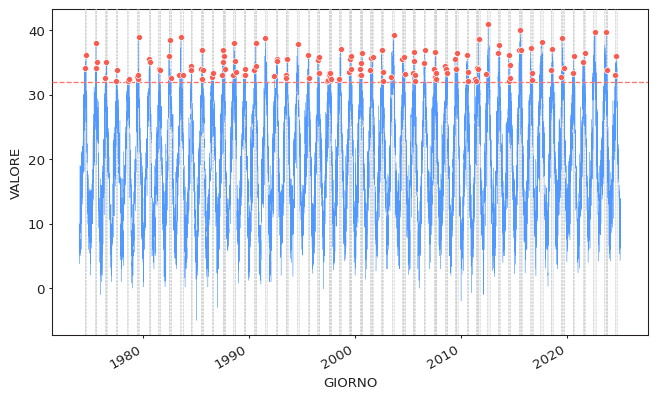

In [85]:
model_urbano1.plot_extremes(show_clusters=True)

In [86]:
print(len(model_urbano1.extremes))
model_urbano1.extremes

148


,VALORE
GIORNO,
1974-07-12,34.2
1974-08-16,36.2
1975-07-10,34.2
1975-07-25,38.0
1975-08-19,35.0
...,...
2023-08-23,39.7
2023-09-11,33.8
2023-10-09,33.8


In [87]:
model_urbano1.extremes.sort_values(ascending=False)

,VALORE
GIORNO,
2012-07-21,41.0
2015-07-22,40.0
2022-08-05,39.8
2023-08-23,39.7
2003-08-11,39.3
...,...
2011-05-25,32.2
2014-07-07,32.2
2010-08-02,32.1


In [88]:
model_urbano1.fit_model()

In [103]:
summary_urbano1 = model_urbano1.get_summary(
    return_period=[1, 2, 5, 10, 50, 100],
    alpha=0.95,
    n_samples=5000,
)

In [104]:
summary_urbano1

,return value,lower ci,upper ci
return period,,,
1.0,35.283120,34.843919,35.811737
2.0,36.812534,36.263066,37.406322
5.0,38.310161,37.660837,38.869090
10.0,39.145833,38.385970,39.683255
50.0,40.420749,39.386579,41.074428
100.0,40.772714,39.597768,41.542425


(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='VALORE'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='VALORE', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

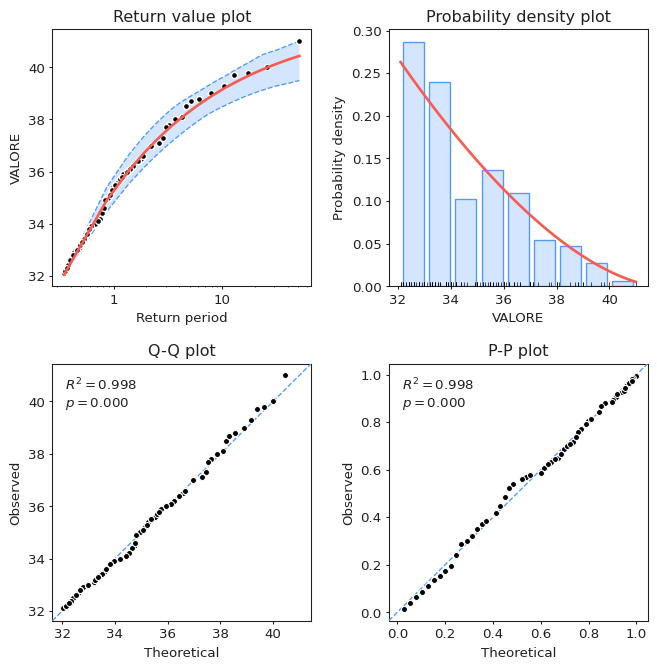

In [105]:
model_urbano1.plot_diagnostic(alpha=0.95)

In [92]:
model_urbano1.distribution

       pyextremes distribution       
-------------------------------------
name: genpareto                      
free parameters: c, scale            
fixed parameters: floc=32.000        
MLE parameters: c=-0.376, scale=3.739
-------------------------------------

In [93]:
from pyextremes import get_return_periods

return_periods = get_return_periods(
    ts=urbano1,
    extremes=model_urbano1.extremes,
    extremes_method="POT",
    extremes_type="high",
    block_size=None,
    return_period_size="365.2425D",
    plotting_position="weibull",
)
return_periods.sort_values("return period", ascending=False).head()

,VALORE,exceedance probability,return period
GIORNO,,,
2012-07-21,41.0,0.006711,51.343582
2015-07-22,40.0,0.013423,25.671791
2022-08-05,39.8,0.020134,17.114527
2023-08-23,39.7,0.026846,12.835895
2003-08-11,39.3,0.033557,10.268716


Provo a guardare la media delle massime giornaliere, sia in ambiente urbano che in ambiente rurale.

In [94]:
rurale1.describe()

,VALORE
count,18262.000000
mean,19.983561
std,9.057537
min,-2.000000
25%,12.000000
50%,20.000000
75%,28.000000
max,42.000000


In [95]:
urbano1.describe()

,VALORE
count,18627.000000
mean,20.073952
std,8.933991
min,-5.000000
25%,12.300000
50%,20.100000
75%,28.000000
max,41.000000


Confronto i valori di ritorno della BM.

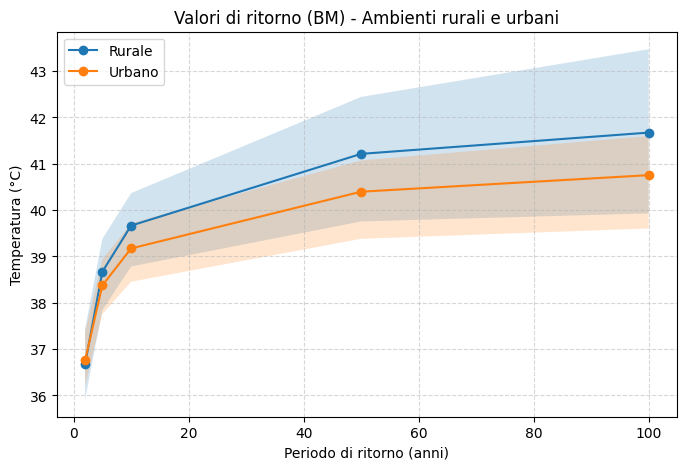

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(summary_rurale.index, summary_rurale['return value'],
         label='Rurale', marker='o')
plt.plot(summary_urbano.index, summary_urbano['return value'],
         label='Urbano', marker='o')

plt.fill_between(summary_rurale.index,
                 summary_rurale['lower ci'], summary_rurale['upper ci'],
                 alpha=0.2)
plt.fill_between(summary_urbano.index,
                 summary_urbano['lower ci'], summary_urbano['upper ci'],
                 alpha=0.2)

plt.xlabel('Periodo di ritorno (anni)')
plt.ylabel('Temperatura (°C)')
plt.title('Valori di ritorno (BM) - Ambienti rurali e urbani')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Ora confronto i valori di ritorno della POT

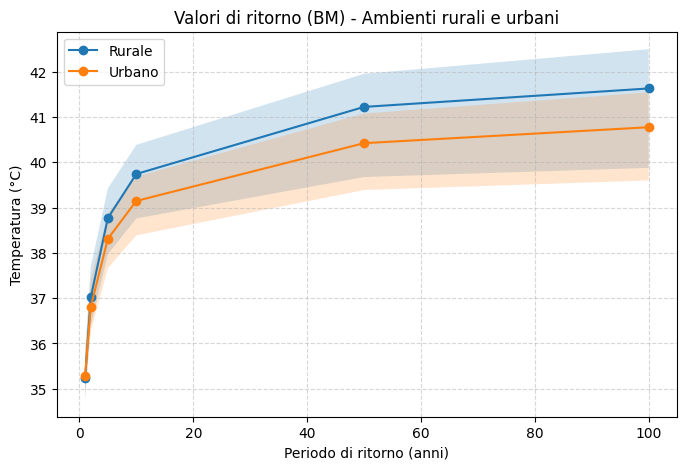

In [106]:
plt.figure(figsize=(8,5))

plt.plot(summary_rurale1.index, summary_rurale1['return value'],
         label='Rurale', marker='o')
plt.plot(summary_urbano1.index, summary_urbano1['return value'],
         label='Urbano', marker='o')

plt.fill_between(summary_rurale1.index,
                 summary_rurale1['lower ci'], summary_rurale1['upper ci'],
                 alpha=0.2)
plt.fill_between(summary_urbano1.index,
                 summary_urbano1['lower ci'], summary_urbano1['upper ci'],
                 alpha=0.2)

plt.xlabel('Periodo di ritorno (anni)')
plt.ylabel('Temperatura (°C)')
plt.title('Valori di ritorno (BM) - Ambienti rurali e urbani')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In entrambi i casi i valori di ritorno sono maggiori in ambienti rurali piuttosto che in ambienti urbani.